## Download data from kagglehub 

In [1]:
%pip install -r requirements.txt

  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-macosx_11_0_arm64.whl.metadata (2.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached starlette-1.7.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached uvicorn-0.54.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 1.7 MB/s  0:00:18m0:00:0100:01
Using cached anyio-4.15.1-py3-none-any.whl (132 kB)
Using cached audioop_lts-0.2.2-cp313-abi3-macosx_11

In [3]:
import kagglehub
import os

# Download latest version

if not os.path.exists("data/fer2013/train"):
    kagglehub.dataset_download("msambare/fer2013", output_dir="data/fer2013")

print("Dataset ready")

Dataset ready


/Users/mateobansard/Documents/ENSTA/Apprentissage_Rob/proj_facial_expression_detection/RO11_2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

from skimage import io
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
import numpy as np

dossier = "data/fer2013/train"
classes = sorted(
    c for c in os.listdir(dossier)
    if os.path.isdir(os.path.join(dossier, c))
)
print(classes)

# LBD + Histogrammes

N_BLOCS = 16
grille = int(np.sqrt(N_BLOCS))

def caracteristiques_lbp(img, grille=grille, P=8, R=1):
    h, w = img.shape
    taille_h, taille_w = h // grille, w // grille
    histogrammes = []
    for i in range(grille):
        for j in range(grille):
            bloc = img[i*taille_h:(i+1)*taille_h, j*taille_w:(j+1)*taille_w]
            lbp_bloc = local_binary_pattern(bloc, P, R, method="default")
            hist, _ = np.histogram(lbp_bloc, bins=256, range=(0, 256))
            histogrammes.append(hist / hist.sum())
    return np.concatenate(histogrammes)

# Import images of the train repository

def charger_dataset(dossier):
    X, y = [], []
    classes = sorted(c for c in os.listdir(dossier)
                     if os.path.isdir(os.path.join(dossier, c)))
    for label in classes:
        dossier_classe = os.path.join(dossier, label)
        fichiers = [f for f in os.listdir(dossier_classe)
                    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for f in fichiers:
            img = io.imread(os.path.join(dossier_classe, f))
            X.append(caracteristiques_lbp(img))
            y.append(label)
        print(f"{label} : {len(fichiers)} images")
    return np.array(X), np.array(y)


X_train, Y_train = charger_dataset("data/fer2013/train")
print("X :", X_train.shape, "| y :", Y_train.shape)
X_test, Y_test = charger_dataset("data/fer2013/test")
print("X :", X_test.shape, "| y :", Y_test.shape)


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
angry : 3995 images
disgust : 436 images
fear : 4097 images
happy : 7215 images
neutral : 4965 images
sad : 4830 images
surprise : 3171 images
X : (28709, 4096) | y : (28709,)
angry : 958 images
disgust : 111 images
fear : 1024 images
happy : 1774 images
neutral : 1233 images
sad : 1247 images
surprise : 831 images
X : (7178, 4096) | y : (7178,)


angry


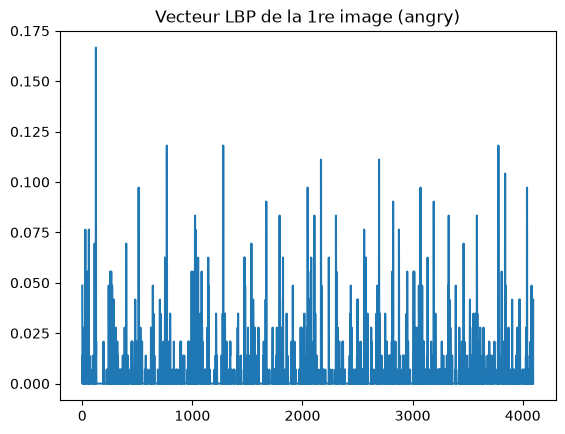

In [5]:
# Test

print(Y_train[0])           
plt.plot(X_train[0])
plt.title(f"Vecteur LBP de la 1re image ({Y_train[0]})")
plt.show()

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

y_pred = knn.predict(X_test)
print("Précision :", accuracy_score(Y_test, y_pred))

Précision : 0.40025076623014766


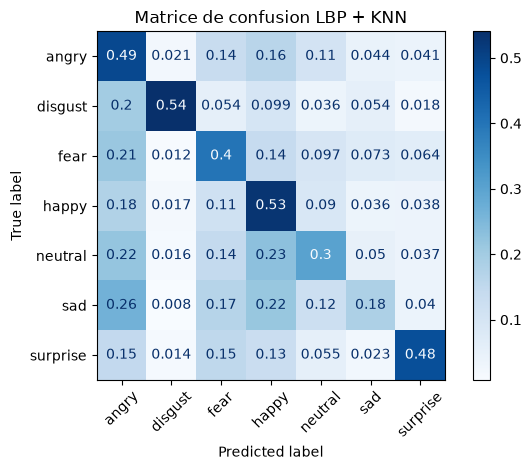

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(Y_test, y_pred, labels=classes, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion LBP + KNN")
plt.tight_layout()
plt.show()

In [8]:
import joblib

modele = {"knn": knn, "grille": grille, "P": 8, "R": 1}
joblib.dump(modele, "modele_lbp_knn.joblib", compress=3)

print("Modèle sauvegardé")

Modèle sauvegardé


In [9]:
from skimage.color import rgb2gray
from skimage.transform import resize

def predire_emotion(chemin_image, modele):
    img = io.imread(chemin_image)

    # niveaux de gris
    if img.ndim == 3:
        img = (rgb2gray(img[..., :3]) * 255).astype(np.uint8)

    # redimensionner en 48x48 
    img = resize(img, (48, 48), anti_aliasing=True, preserve_range=True).astype(np.uint8)

    vecteur = caracteristiques_lbp(img, grille=modele["grille"], P=modele["P"], R=modele["R"])
    return modele["knn"].predict([vecteur])[0]


# Test
modele_charge = joblib.load("modele_lbp_knn.joblib")
chemin = "data/fer2013/test/happy/" + os.listdir("data/fer2013/test/happy")[0]
print("Émotion prédite :", predire_emotion(chemin, modele_charge))

Émotion prédite : happy
